 <span style="font-size:30px;font-weight:bold;color:blue;">FRAUD DETECTION</span>


Data source: MySQL (fraud_analysis transactions table) pulled into a pandas DataFrame Dataset
(11,142 rows, 10.25% fraud rate)

This notebook covers:

 * Load data from MySQL.
 * Exploratory Data Analysis (EDA).
 * Feature Engineering.
 * visualization of features correlation.
 * Three different model.
   -> logistic regression.
   -> Random forest classifier.
   -> XGboost classifier.
* Training Model.
* evaluating model.
* comparing Model.

 <span style="font-size:30px;font-weight:bold;color:blue;">OBJECTIVE</span>
   
   
   The objective of this project is to develop an end-to-end machine learning pipeline for detecting fraudulent financial transactions. The project extracts transaction data from a SQL database, performs data analysis and visualization, applies feature engineering and preprocessing, and trains multiple machine learning models.The goal is to develop a robust machine learning model to accurately identify fraudulent transactions in real-time , enabling the company to improve security, reduce financial losses, and gain insights into factors contributing to transaction fraud.SThe models are evaluated using Precision, Recall, F1-Score, ROC-AUC, and PR-AUC, and the best-performing model is selected for deployment.
     




In [95]:
!pip install mysql-connector-python

In [96]:
!pip install scikit-learn

 <span style="font-size:30px;font-weight:bold;color:blue;">Connecting MYSQL</span>

In [4]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Connect to MySQL
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="132831",
    database="fraud_analysis"
)

print("Connected successfully!")

# Create cursor
cursor = connection.cursor()

# Run SQL query
cursor.execute("SELECT * FROM transactions ")

# Get data
rows = cursor.fetchall()

# Display data
for row in rows:
    print(row)

query = "SELECT * FROM transactions"

df = pd.read_sql(query, connection)

print(df)
# Close connection
cursor.close()
connection.close()

Connected successfully!
(1, 'TRANSFER', 181.0, 'C1305486145', 181.0, 0.0, 'C553264065', 0.0, 0.0, 1)
(1, 'CASH_OUT', 181.0, 'C840083671', 181.0, 0.0, 'C38997010', 21182.0, 0.0, 1)
(1, 'TRANSFER', 2806.0, 'C1420196421', 2806.0, 0.0, 'C972765878', 0.0, 0.0, 1)
(1, 'CASH_OUT', 2806.0, 'C2101527076', 2806.0, 0.0, 'C1007251739', 26202.0, 0.0, 1)
(1, 'TRANSFER', 20128.0, 'C137533655', 20128.0, 0.0, 'C1848415041', 0.0, 0.0, 1)
(1, 'CASH_OUT', 20128.0, 'C1118430673', 20128.0, 0.0, 'C339924917', 6268.0, 12145.85, 1)
(1, 'CASH_OUT', 416001.33, 'C749981943', 0.0, 0.0, 'C667346055', 102.0, 9291619.62, 1)
(1, 'TRANSFER', 1277212.77, 'C1334405552', 1277212.77, 0.0, 'C431687661', 0.0, 0.0, 1)
(1, 'CASH_OUT', 1277212.77, 'C467632528', 1277212.77, 0.0, 'C716083600', 0.0, 2444985.19, 1)
(1, 'TRANSFER', 35063.63, 'C1364127192', 35063.63, 0.0, 'C1136419747', 0.0, 0.0, 1)
(1, 'CASH_OUT', 35063.63, 'C1635772897', 35063.63, 0.0, 'C1983025922', 31140.0, 7550.03, 1)
(1, 'TRANSFER', 25071.46, 'C669700766', 2507

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18608\4151703007.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


<span style="font-size:32px;font-weight:bold;color:blue;">Exploratory Data Analysis (EDA) process</span>

In [2]:
df

,step,type,amount,nameorig,oldbalanceorg,newbalanceorg,namedest,oldbalancedest,newbalancedest,isfraude
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0


In [5]:
df.describe()

,step,amount,oldbalanceorg,newbalanceorg,oldbalancedest,newbalancedest,isfraude
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameorig          0
oldbalanceorg     0
newbalanceorg     0
namedest          0
oldbalancedest    0
newbalancedest    0
isfraude          0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameorig        11142 non-null  object 
 4   oldbalanceorg   11142 non-null  float64
 5   newbalanceorg   11142 non-null  float64
 6   namedest        11142 non-null  object 
 7   oldbalancedest  11142 non-null  float64
 8   newbalancedest  11142 non-null  float64
 9   isfraude        11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
11137    False
11138    False
11139    False
11140    False
11141    False
Length: 11142, dtype: bool

In [7]:
df.shape

(11142, 10)

In [5]:
df["isfraude"].value_counts()

isfraude
0    10000
1     1142
Name: count, dtype: int64

In [10]:
###Now calculate percentage###

df["isfraude"].value_counts(normalize=True)*100

###it has 89.75% of nonfraud 10% of fraud ,so it is imbalanced classification problem ###

isfraude
0    89.750494
1    10.249506
Name: proportion, dtype: float64

In [11]:
df["type"].value_counts()

type
PAYMENT     5510
CASH_IN     1951
CASH_OUT    1871
TRANSFER    1464
DEBIT        346
Name: count, dtype: int64

In [12]:
### finding fraud rate percentage by its type


fraud_rate = (df.groupby("type")["isfraude"].mean().sort_values(ascending=False))
print(fraud_rate)

type
TRANSFER    0.385246
CASH_OUT    0.308926
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isfraude, dtype: float64


<span style="font-size:32px;font-weight:bold;color:blue;">visualization</span>

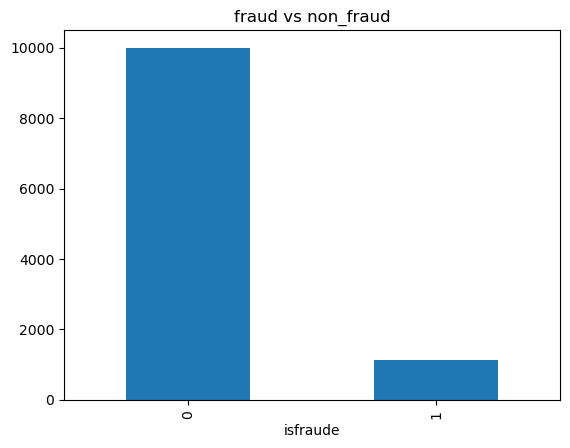

In [13]:
###visualization of  fraud vs non-fraud 
df['isfraude'].value_counts().plot(kind='bar')
plt.title('fraud vs non_fraud')
plt.show()

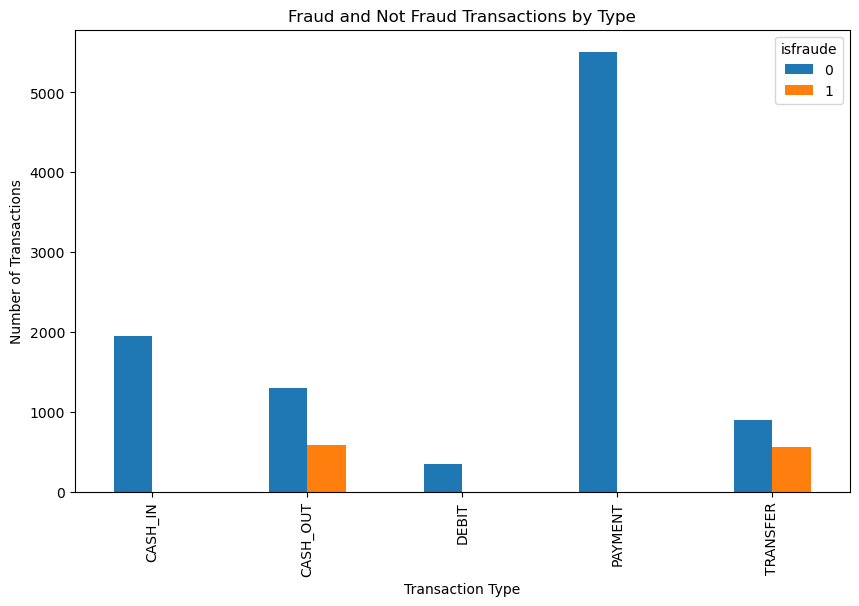

In [14]:
###visualization of  fraud by type of transactions
fraud_type=pd.crosstab(df['type'],df['isfraude'])
fraud_type.plot(kind='bar', figsize=(10, 6))
plt.title('Fraud and Not Fraud Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

In [15]:
df['amount'].describe()

count    1.114200e+04
mean     2.131915e+05
std      7.600650e+05
min      2.390000e+00
25%      4.946618e+03
50%      1.676126e+04
75%      1.543366e+05
max      1.000000e+07
Name: amount, dtype: float64

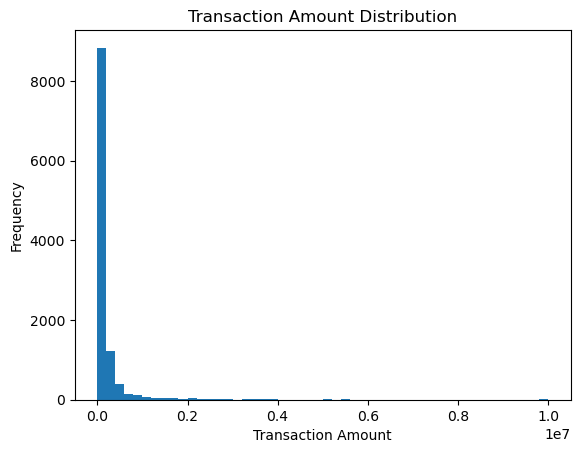

In [16]:
plt.hist(df['amount'],bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

<span style="font-size:32px;font-weight:bold;color:blue;">Feature Engineering</span>

In [17]:
### created two new features
df['orgin_balance_change']=(df['oldbalanceorg']-df['newbalanceorg'])
df['dest_balance_change']=(df['oldbalancedest']-df['newbalancedest'])
df

,step,type,amount,nameorig,oldbalanceorg,newbalanceorg,namedest,oldbalancedest,newbalancedest,isfraude,orgin_balance_change,dest_balance_change
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,181.00,0.00
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,181.00,21182.00
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,2806.00,0.00
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,2806.00,26202.00
4,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0,6393.70,267885.75
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0,298799.54,-4566008.83
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0,127891.14,-139142.53
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0,1094.03,0.00


In [18]:
### Summary statistics by fraud status
df.groupby('isfraude')[['orgin_balance_change','dest_balance_change']].mean()

,orgin_balance_change,dest_balance_change
isfraude,,
0,-2.480818e+04,-168010.620135
1,1.184692e+06,-625074.346051


In [15]:
### checking correcorrelation with fraud
df[['amount','isfraude','orgin_balance_change','dest_balance_change']].corr()

,amount,isfraude,orgin_balance_change,dest_balance_change
amount,1.000000,0.435490,0.943694,-0.387728
isfraude,0.435490,1.000000,0.487231,-0.124020
orgin_balance_change,0.943694,0.487231,1.000000,-0.320916
dest_balance_change,-0.387728,-0.124020,-0.320916,1.000000


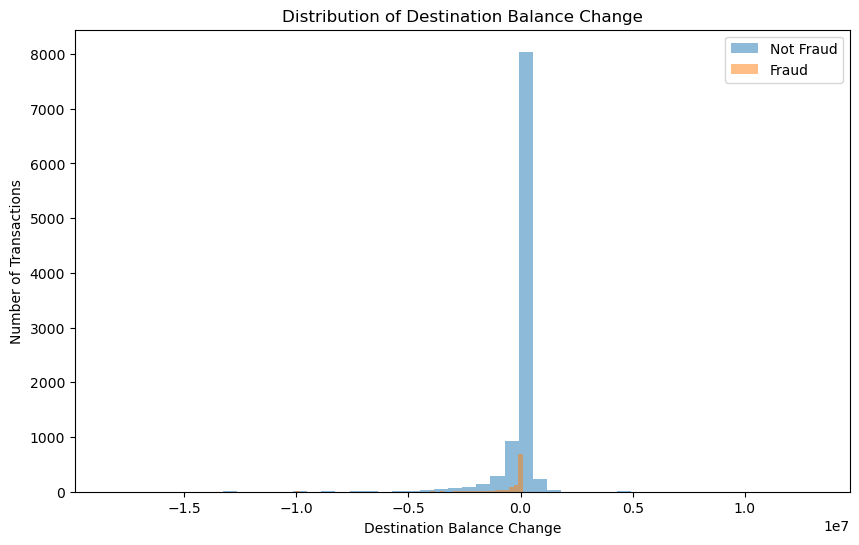

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(df[df["isfraude"] == 0]["dest_balance_change"],bins=50,alpha=0.5,label="Not Fraud")
plt.hist(df[df["isfraude"] == 1]["dest_balance_change"],bins=50,alpha=0.5,label="Fraud")
plt.title("Distribution of Destination Balance Change")
plt.xlabel("Destination Balance Change")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

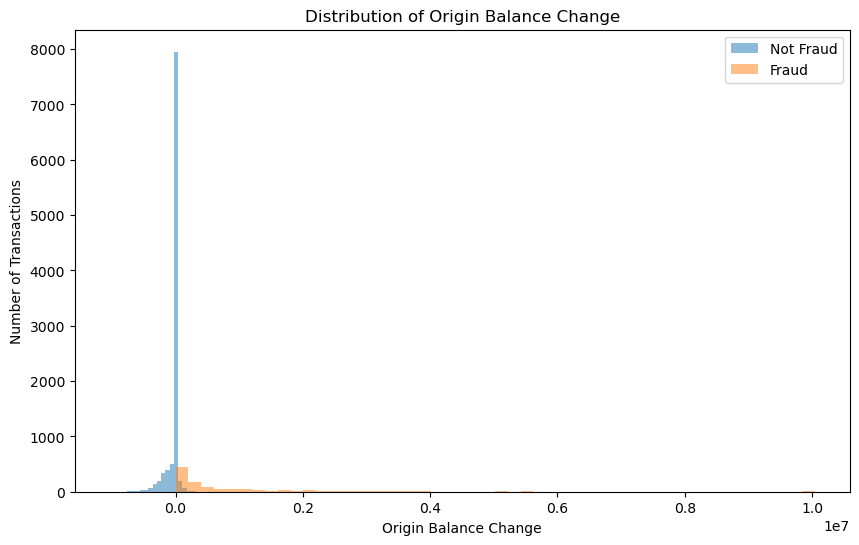

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(df[df["isfraude"] == 0]["orgin_balance_change"],bins=50,alpha=0.5,label="Not Fraud")
plt.hist(df[df["isfraude"] == 1]["orgin_balance_change"],bins=50,alpha=0.5,label="Fraud")
plt.title("Distribution of Origin Balance Change")
plt.xlabel("Origin Balance Change")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

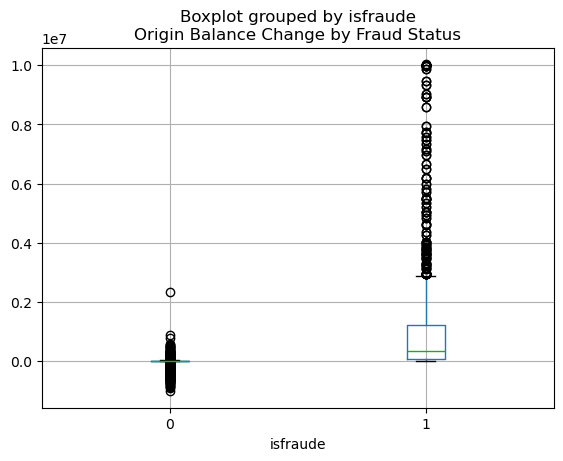

In [19]:
###visualization of new features
df.boxplot(column='orgin_balance_change',by='isfraude')
plt.title("Origin Balance Change by Fraud Status")
plt.show()

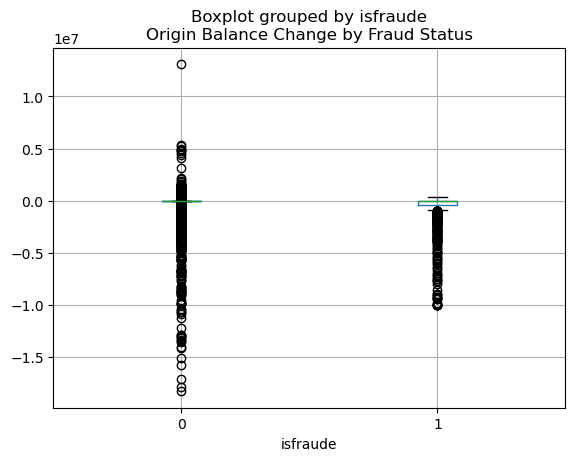

In [20]:
df.boxplot(column='dest_balance_change',by='isfraude')
plt.title("Origin Balance Change by Fraud Status")
plt.show()

In [22]:
###droping unwanted columns
df_1=df.drop(columns=['nameorig','namedest'])
df_1

,step,type,amount,oldbalanceorg,newbalanceorg,oldbalancedest,newbalancedest,isfraude,orgin_balance_change,dest_balance_change
0,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,181.00,0.00
1,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,181.00,21182.00
2,1,TRANSFER,2806.00,2806.00,0.00,0.00,0.00,1,2806.00,0.00
3,1,CASH_OUT,2806.00,2806.00,0.00,26202.00,0.00,1,2806.00,26202.00
4,1,TRANSFER,20128.00,20128.00,0.00,0.00,0.00,1,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,433084.38,426690.68,478421.00,210535.25,0,6393.70,267885.75
11138,7,CASH_OUT,298799.54,426690.68,127891.14,704355.36,5270364.19,0,298799.54,-4566008.83
11139,7,CASH_OUT,423159.63,127891.14,0.00,610479.00,749621.53,0,127891.14,-139142.53
11140,7,PAYMENT,1094.03,13918.00,12823.97,0.00,0.00,0,1094.03,0.00


In [23]:
### splitting data to train and test

x=df_1.drop(columns=['isfraude', 'newbalancedest', 'newbalanceorg'])
y=df_1['isfraude']


x=pd.get_dummies(x,columns=['type'],drop_first=True)
# Scale numerical columns
numerical_cols=['step', 'amount', 'oldbalanceorg',
                   'oldbalancedest']
scaler = StandardScaler()
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])
print(x.head())
print(x.shape)





       step    amount  oldbalanceorg  oldbalancedest  orgin_balance_change  \
0 -0.480349 -0.280266      -0.431160       -0.341509                 181.0   
1 -0.480349 -0.280266      -0.431160       -0.333366                 181.0   
2 -0.480349 -0.276812      -0.429935       -0.341509                2806.0   
3 -0.480349 -0.276812      -0.429935       -0.331436                2806.0   
4 -0.480349 -0.254021      -0.421852       -0.341509               20128.0   

   dest_balance_change  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER  
0                  0.0          False       False         False           True  
1              21182.0           True       False         False          False  
2                  0.0          False       False         False           True  
3              26202.0           True       False         False          False  
4                  0.0          False       False         False           True  
(11142, 10)


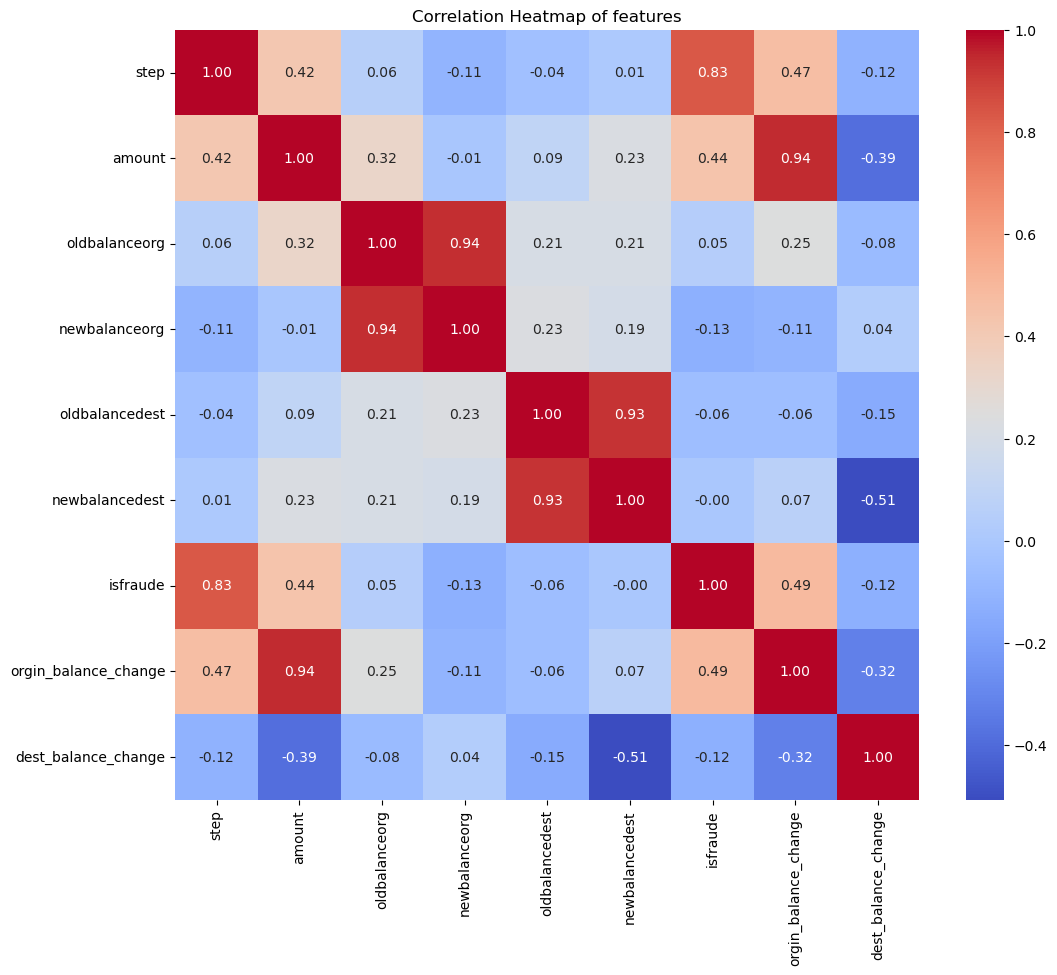

In [24]:
# Combine encoded features with target for full picture
correlation = df_1.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation,annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of features')
plt.show()

<span style="font-size:32px;font-weight:bold;color:blue;">Train Logistic Regression Model</span>

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])


In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

C:\Users\LENOVO\Documents\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<span style="font-size:30px;font-weight:bold;color:blue;">making prediction</span>

In [27]:
### testing the testdata
y_pred = model.predict(x_test)
print(y_pred)

[0 0 0 ... 0 0 1]


In [28]:
###predicting probabilities
y_pred_prob= model.predict_proba(x_test)[:, 1]
print(y_pred_prob)

[1.02844553e-03 3.57828474e-03 1.51466922e-02 ... 5.89987277e-05
 4.55064057e-03 9.91365521e-01]


<span style="font-size:30px;font-weight:bold;color:blue;">Evaluating the model</span>

In [29]:
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve,average_precision_score)
report=classification_report(y_pred,y_test)
print(report)


              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2026
           1       0.88      0.99      0.93       203

    accuracy                           0.99      2229
   macro avg       0.94      0.99      0.96      2229
weighted avg       0.99      0.99      0.99      2229



In [58]:
print("ROC-AUC:",roc_auc_score(y_test, y_pred_prob))
print("PR-AUC:",average_precision_score(y_test, y_pred_prob))

ROC-AUC: 0.9927777339400475
PR-AUC: 0.9738715734748383


In [30]:
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[1999    2]
 [  27  201]]


In [60]:
print("Train accuracy:", model.score(x_train, y_train))
print("Test accuracy:", model.score(x_test, y_test))

Train accuracy: 0.9896779984292606
Test accuracy: 0.9869896814715119


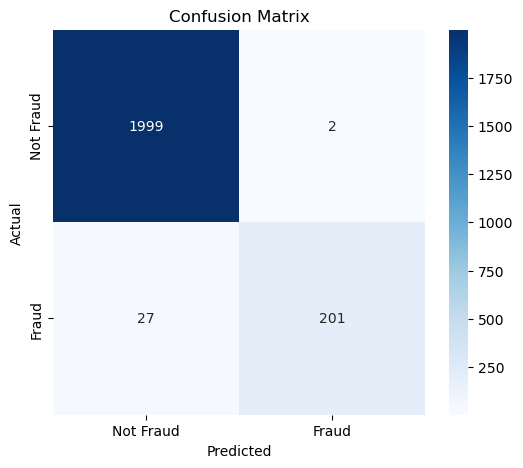

In [31]:
###visualizing the heatmap for confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

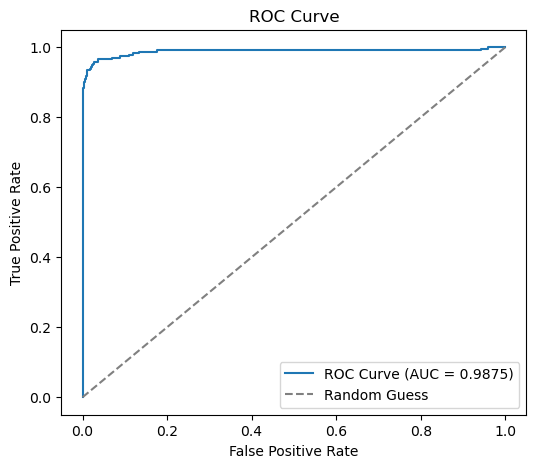

In [33]:
###visualizing ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

<span style="font-size:30px;font-weight:bold;color:blue;">RandomForest Model</span>

In [35]:
df_1

,step,type,amount,oldbalanceorg,newbalanceorg,oldbalancedest,newbalancedest,isfraude,orgin_balance_change,dest_balance_change
0,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,181.00,0.00
1,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,181.00,21182.00
2,1,TRANSFER,2806.00,2806.00,0.00,0.00,0.00,1,2806.00,0.00
3,1,CASH_OUT,2806.00,2806.00,0.00,26202.00,0.00,1,2806.00,26202.00
4,1,TRANSFER,20128.00,20128.00,0.00,0.00,0.00,1,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,433084.38,426690.68,478421.00,210535.25,0,6393.70,267885.75
11138,7,CASH_OUT,298799.54,426690.68,127891.14,704355.36,5270364.19,0,298799.54,-4566008.83
11139,7,CASH_OUT,423159.63,127891.14,0.00,610479.00,749621.53,0,127891.14,-139142.53
11140,7,PAYMENT,1094.03,13918.00,12823.97,0.00,0.00,0,1094.03,0.00


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

In [45]:
x=df_1.drop(columns=['isfraude','orgin_balance_change', 'dest_balance_change'])
y=df_1['isfraude']


x=pd.get_dummies(x,columns=['type'],drop_first=True)
# Scale numerical columns
numerical_cols=['step', 'amount','oldbalanceorg', 'oldbalancedest','newbalanceorg','newbalancedest']
scaler = StandardScaler()
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])
print(x.head())
print(x.shape)



       step    amount  oldbalanceorg  newbalanceorg  oldbalancedest  \
0 -0.480349 -0.280266      -0.431160      -0.394754       -0.341509   
1 -0.480349 -0.280266      -0.431160      -0.394754       -0.333366   
2 -0.480349 -0.276812      -0.429935      -0.394754       -0.341509   
3 -0.480349 -0.276812      -0.429935      -0.394754       -0.331436   
4 -0.480349 -0.254021      -0.421852      -0.394754       -0.341509   

   newbalancedest  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER  
0       -0.369918          False       False         False           True  
1       -0.369918           True       False         False          False  
2       -0.369918          False       False         False           True  
3       -0.369918           True       False         False          False  
4       -0.369918          False       False         False           True  
(11142, 10)


In [46]:
print(x)

           step    amount  oldbalanceorg  newbalanceorg  oldbalancedest  \
0     -0.480349 -0.280266      -0.431160      -0.394754       -0.341509   
1     -0.480349 -0.280266      -0.431160      -0.394754       -0.333366   
2     -0.480349 -0.276812      -0.429935      -0.394754       -0.341509   
3     -0.480349 -0.276812      -0.429935      -0.394754       -0.331436   
4     -0.480349 -0.254021      -0.421852      -0.394754       -0.341509   
...         ...       ...            ...            ...             ...   
11137 -0.106907 -0.272091      -0.229143      -0.190577       -0.157590   
11138 -0.106907  0.112638      -0.232127      -0.333557       -0.070734   
11139 -0.106907  0.276263      -0.371563      -0.394754       -0.106823   
11140 -0.106907 -0.279064      -0.424750      -0.388618       -0.341509   
11141 -0.106907 -0.268352      -0.412595      -0.380051       -0.341509   

       newbalancedest  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER  
0           -0.3699

In [75]:
### training the model
### we are using class_weight='balance' to balance the data,because we have imbalance dataset
model_2=RandomForestClassifier(n_estimators=200,
    max_depth=10,
    class_weight="balanced", min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
model_2.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
###testing model
y_pred_model2=model_2.predict(x_test)
y_pred_prob_model2=model_2.predict_proba(x_test)[:, 1]

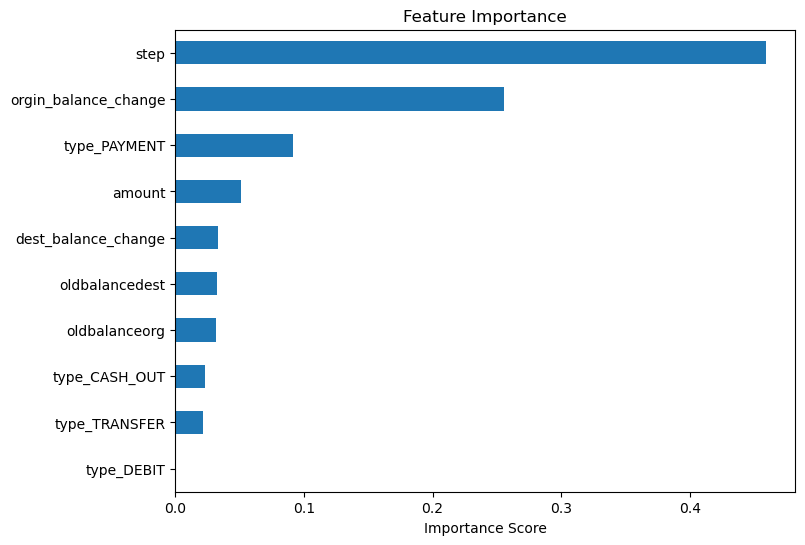

In [67]:
###Random Forest tells you which features mattered most
importances = pd.Series(model_2.feature_importances_, index=x_train.columns)
importances = importances.sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

<span style="font-size:30px;font-weight:bold;color:blue;">Evaluating Model</span>

In [79]:
print(classification_report(y_test, y_pred_model2))
print(confusion_matrix(y_test, y_pred_model2))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob_model2))
print("PR-AUC:", average_precision_score(y_test, y_pred_prob_model2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

[[2001    0]
 [   6  222]]
ROC-AUC: 0.9998509517171239
PR-AUC: 0.9988321383924603


In [80]:
# Training predictions
y_train_pred =model_2.predict(x_train)

# Test predictions
y_test_pred =model_2.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("===== RANDOM FOREST =====")

print("\nTraining Performance")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

print("\nTesting Performance")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

===== RANDOM FOREST =====

Training Performance
Accuracy : 0.9998878043307529
Precision: 0.9989071038251366
Recall   : 1.0
F1 Score : 0.9994532531437944

Testing Performance
Accuracy : 0.9973082099596231
Precision: 1.0
Recall   : 0.9736842105263158
F1 Score : 0.9866666666666667


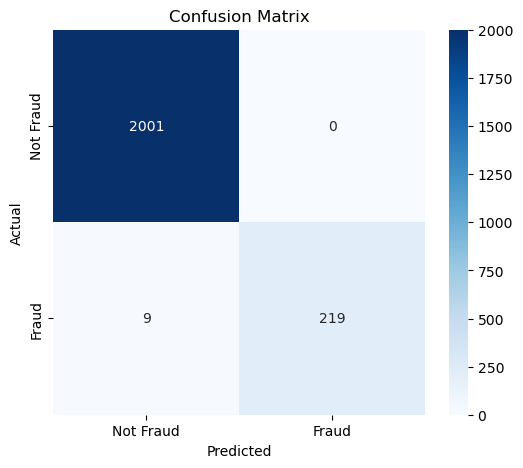

In [60]:
###visualizing the heatmap for confusion matrix
cm_2=confusion_matrix(y_test, y_pred_model2)
plt.figure(figsize=(6,5))
sns.heatmap(cm_2,annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

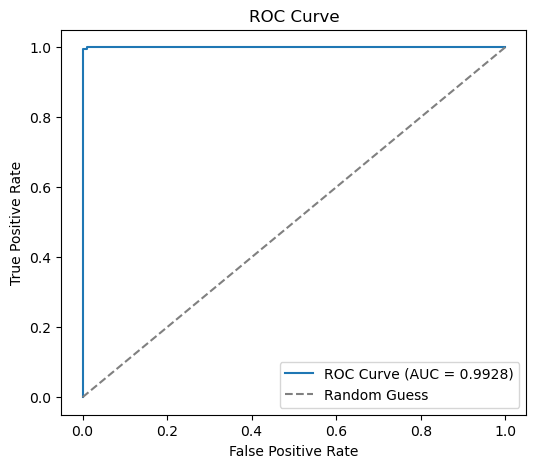

In [69]:
###visualizing ROC Curve
fpr, tpr, thresholds_2 = roc_curve(y_test, y_pred_prob_model2)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [43]:
###Because your scores are exceptionally high, I strongly recommend checking data leakage

print("Features used by model:")
print(x.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nDuplicate rows:")
print(df.duplicated().sum())

Features used by model:
['step', 'amount', 'oldbalanceorg', 'newbalanceorg', 'oldbalancedest', 'newbalancedest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Target:
isfraude

Duplicate rows:
0


<span style="font-size:30px;font-weight:bold;color:blue;">Xgboost Model</span>

In [56]:
!pip install xgboost

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score



In [45]:
x=df_1.drop(columns=['isfraude','orgin_balance_change', 'dest_balance_change'])
y=df_1['isfraude']


x=pd.get_dummies(x,columns=['type'],drop_first=True)
# Scale numerical columns
numerical_cols=['step', 'amount','oldbalanceorg', 'newbalanceorg', 'oldbalancedest', 'newbalancedest']
scaler = StandardScaler()
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])
print(x.head())
print(x.shape)

       step    amount  oldbalanceorg  newbalanceorg  oldbalancedest  \
0 -0.480349 -0.280266      -0.431160      -0.394754       -0.341509   
1 -0.480349 -0.280266      -0.431160      -0.394754       -0.333366   
2 -0.480349 -0.276812      -0.429935      -0.394754       -0.341509   
3 -0.480349 -0.276812      -0.429935      -0.394754       -0.331436   
4 -0.480349 -0.254021      -0.421852      -0.394754       -0.341509   

   newbalancedest  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER  
0       -0.369918          False       False         False           True  
1       -0.369918           True       False         False          False  
2       -0.369918          False       False         False           True  
3       -0.369918           True       False         False          False  
4       -0.369918          False       False         False           True  
(11142, 10)


In [46]:
###testing model
xgb_model_3= XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42,eval_metric='logloss')
xgb_model_3.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [47]:
y_pred_xgb=xgb_model_3.predict(x_test)
y_pred_prob_xgb = xgb_model_3.predict_proba(x_test)[:, 1]

<span style="font-size:30px;font-weight:bold;color:blue;">Evaluating Model</span>

In [48]:
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_pred_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       1.00      0.96      0.98       230

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229

[[1999    0]
 [   9  221]]
ROC-AUC: 0.9997498749374687
PR-AUC: 0.9982823832789526


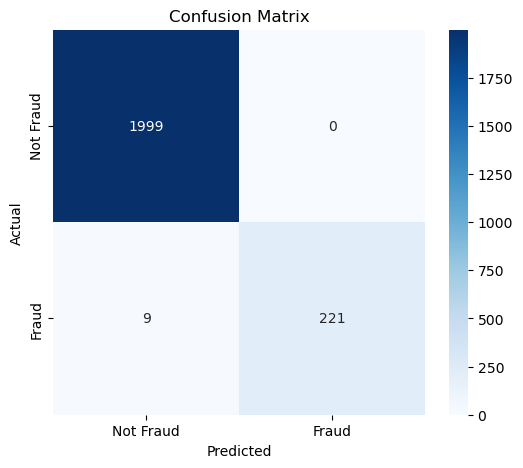

In [49]:
###visualizing the heatmap for confusion matrix
cm_3=confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_3,annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<span style="font-size:30px;font-weight:bold;color:blue;">Evaluating Classification reports Of All Three Model</span>

In [50]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_model2))

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1999
           1       1.00      0.86      0.92       230

    accuracy                           0.99      2229
   macro avg       0.99      0.93      0.96      2229
weighted avg       0.99      0.99      0.98      2229

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       1.00      0.96      0.98       230

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       1.00      0.96      0.98       230

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted

<span style="font-size:30px;font-weight:bold;color:blue;">ROC-AUC And PR-AUC Comparison For All 3 Models</span>

In [51]:

print("Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("PR-AUC:", average_precision_score(y_test, y_pred_prob))

print("\nRandom Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob_model2))
print("PR-AUC:", average_precision_score(y_test,y_pred_prob_model2))

print("\nXGBoost")
print("ROC-AUC:", roc_auc_score(y_test,y_pred_prob_xgb))
print("PR-AUC:", average_precision_score(y_test,y_pred_prob_xgb))

Logistic Regression
ROC-AUC: 0.9875024468756117
PR-AUC: 0.9698444460948544

Random Forest
ROC-AUC: 0.999904299976075
PR-AUC: 0.9992962739843646

XGBoost
ROC-AUC: 0.9997498749374687
PR-AUC: 0.9982823832789526


<span style="font-size:30px;font-weight:bold;color:blue;">PR-AUC comparsion For All 3 Models</span>


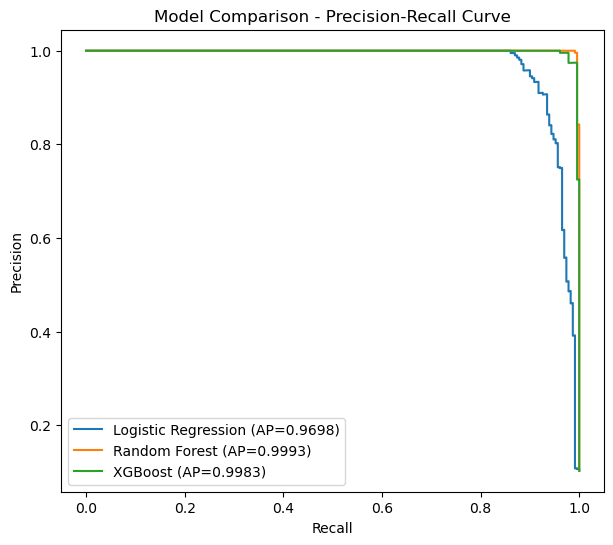

In [52]:
from sklearn.metrics import precision_recall_curve
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_prob)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_prob_model2)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_prob_xgb)

plt.figure(figsize=(7,6))
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP={average_precision_score(y_test, y_pred_prob):.4f})')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP={average_precision_score(y_test, y_pred_prob_model2):.4f})')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={average_precision_score(y_test, y_pred_prob_xgb):.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Model Comparison - Precision-Recall Curve')
plt.legend()
plt.show()